## 1. Download Dataset

In [1]:
# ============================================================
# 3.0 KonIQ-10k Dataset Download and Extraction
# Full-resolution version: 1024x768
# Single-line progress bar for notebook
# ============================================================

from pathlib import Path
import requests
import zipfile
import shutil
import warnings
from tqdm.auto import tqdm
from urllib3.exceptions import InsecureRequestWarning

# Suppress SSL warnings because the dataset host certificate is expired
warnings.simplefilter("ignore", InsecureRequestWarning)

DATA_ROOT = Path("data/koniq10k")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

FULL_IMG_URL = "https://datasets.vqa.mmsp-kn.de/archives/koniq10k_1024x768.zip"
SCORES_URL   = "https://datasets.vqa.mmsp-kn.de/archives/koniq10k_scores_and_distributions.zip"

FULL_IMG_ZIP = DATA_ROOT / "koniq10k_1024x768.zip"
SCORES_ZIP   = DATA_ROOT / "koniq10k_scores_and_distributions.zip"

IMG_DIR  = DATA_ROOT / "1024x768"
CSV_PATH = DATA_ROOT / "koniq10k_scores_and_distributions.csv"


def download_file(url: str, out_path: Path, force_redownload: bool = False):
    """
    Download a file with a single-line tqdm progress bar.
    Uses verify=False because the remote certificate is expired.
    """
    out_path = Path(out_path)

    if out_path.exists() and not force_redownload:
        print(f"[Skip] Already exists: {out_path} ({out_path.stat().st_size / (1024**2):.2f} MB)")
        return

    if out_path.exists() and force_redownload:
        out_path.unlink()

    tmp_path = out_path.with_suffix(out_path.suffix + ".part")

    if tmp_path.exists():
        tmp_path.unlink()

    with requests.get(url, stream=True, verify=False, timeout=60) as r:
        r.raise_for_status()

        total = int(r.headers.get("Content-Length", 0))
        content_type = r.headers.get("Content-Type", "")

        # Basic sanity check: if server returns HTML/text instead of zip, stop early
        if "text/html" in content_type.lower():
            raise ValueError(f"Expected zip content but got HTML page from: {url}")

        with open(tmp_path, "wb") as f, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
            desc=out_path.name,
            ncols=100,
            leave=False
        ) as pbar:
            for chunk in r.iter_content(chunk_size=1024 * 1024):  # 1 MB chunks
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

    tmp_path.rename(out_path)
    print(f"[Done] Downloaded: {out_path} ({out_path.stat().st_size / (1024**3):.2f} GB)")


def extract_zip(zip_path: Path, target_dir: Path, force_reextract: bool = False):
    """
    Extract zip safely. If zip is invalid, raise an error.
    """
    zip_path = Path(zip_path)
    target_dir = Path(target_dir)

    if force_reextract and target_dir.exists():
        shutil.rmtree(target_dir)

    if target_dir.exists():
        print(f"[Skip] Already extracted: {target_dir}")
        return

    if not zipfile.is_zipfile(zip_path):
        raise ValueError(f"Invalid zip file: {zip_path}")

    print(f"[Extract] {zip_path.name} -> {target_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(target_dir.parent)
    print(f"[Done] Extracted: {target_dir}")


# ------------------------------------------------------------
# Step 1: download files
# ------------------------------------------------------------
download_file(FULL_IMG_URL, FULL_IMG_ZIP, force_redownload=False)
download_file(SCORES_URL, SCORES_ZIP, force_redownload=False)

# ------------------------------------------------------------
# Step 2: extract files
# ------------------------------------------------------------
extract_zip(FULL_IMG_ZIP, IMG_DIR, force_reextract=False)

if not CSV_PATH.exists():
    if not zipfile.is_zipfile(SCORES_ZIP):
        raise ValueError(f"Invalid zip file: {SCORES_ZIP}")
    print(f"[Extract] {SCORES_ZIP.name} -> {DATA_ROOT}")
    with zipfile.ZipFile(SCORES_ZIP, "r") as zf:
        zf.extractall(DATA_ROOT)
    print(f"[Done] CSV extracted to: {CSV_PATH}")
else:
    print(f"[Skip] CSV already exists: {CSV_PATH}")

# ------------------------------------------------------------
# Step 3: verify
# ------------------------------------------------------------
print("\nVerification:")
print("DATA_ROOT :", DATA_ROOT.resolve())
print("FULL_IMG_ZIP exists:", FULL_IMG_ZIP.exists(), f"({FULL_IMG_ZIP.stat().st_size / (1024**3):.2f} GB)" if FULL_IMG_ZIP.exists() else "")
print("SCORES_ZIP   exists:", SCORES_ZIP.exists(), f"({SCORES_ZIP.stat().st_size / (1024**2):.2f} MB)" if SCORES_ZIP.exists() else "")
print("IMG_DIR      exists:", IMG_DIR.exists())
print("CSV_PATH     exists:", CSV_PATH.exists())

if IMG_DIR.exists():
    jpgs = list(IMG_DIR.glob("*.jpg"))
    print("Sample image count (first scan):", len(jpgs[:10]))
    if jpgs:
        print("First sample:", jpgs[0].name)

[Skip] Already exists: data/koniq10k/koniq10k_1024x768.zip (5348.97 MB)
[Skip] Already exists: data/koniq10k/koniq10k_scores_and_distributions.zip (0.29 MB)
[Skip] Already extracted: data/koniq10k/1024x768
[Skip] CSV already exists: data/koniq10k/koniq10k_scores_and_distributions.csv

Verification:
DATA_ROOT : /home/sagemaker-user/Sprint 2/Stage 2/data/koniq10k
FULL_IMG_ZIP exists: True (5.22 GB)
SCORES_ZIP   exists: True (0.29 MB)
IMG_DIR      exists: True
CSV_PATH     exists: True
Sample image count (first scan): 10
First sample: 10004473376.jpg


CSV shape: (10073, 10)

CSV columns:
['image_name', 'c1', 'c2', 'c3', 'c4', 'c5', 'c_total', 'MOS', 'SD', 'MOS_zscore']

CSV head(5):


,image_name,c1,c2,c3,c4,c5,c_total,MOS,SD,MOS_zscore
0,10004473376.jpg,0,0,25,73,7,105,3.828571,0.527278,77.383621
1,10007357496.jpg,0,3,45,47,1,96,3.479167,0.580003,68.728571
2,10007903636.jpg,1,0,20,73,2,96,3.781250,0.527220,78.628571
3,10009096245.jpg,0,0,21,75,13,109,3.926606,0.556218,77.243750
4,100117038.jpg,0,1,21,72,6,100,3.830000,0.532860,75.112500



Valid rows with existing images: 10073
Using target column: MOS


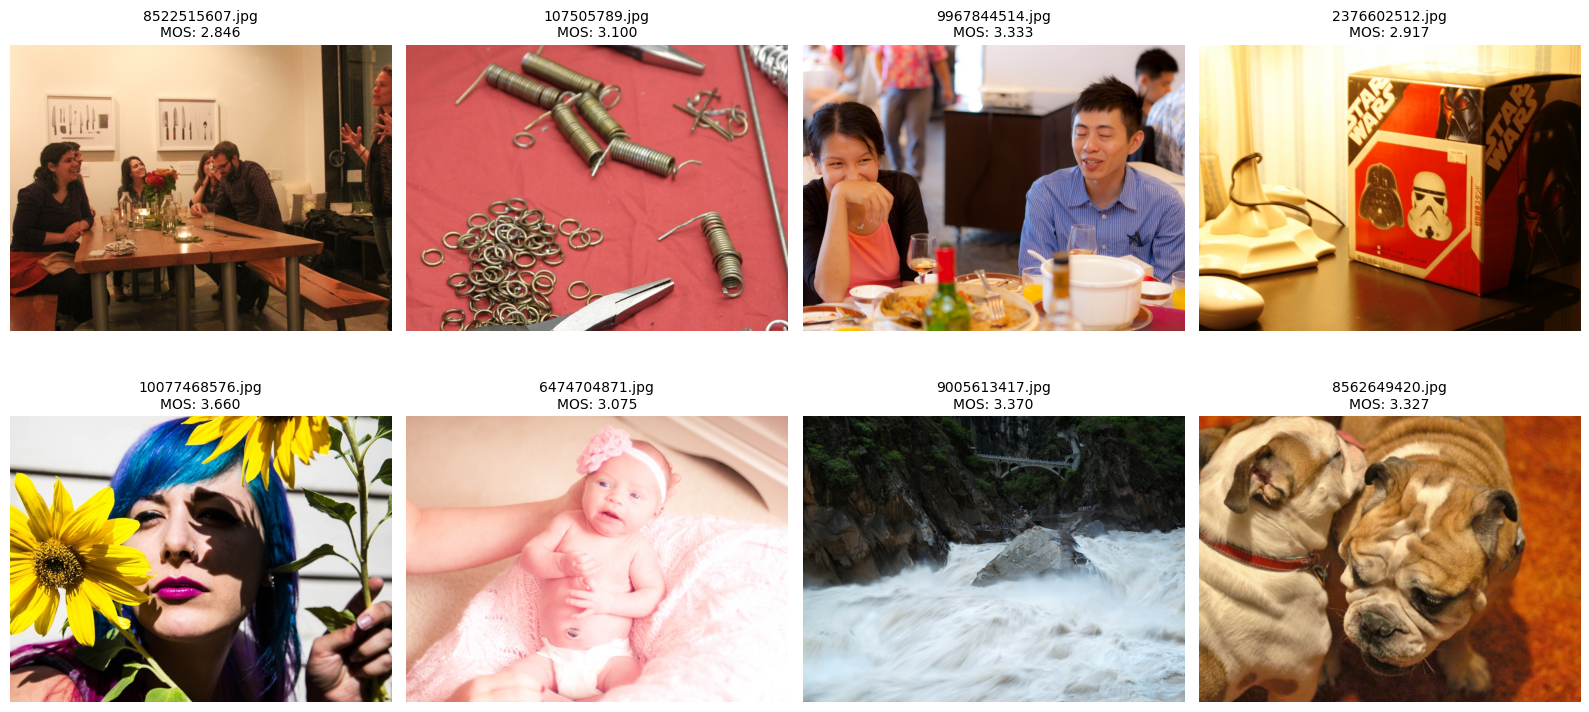

In [2]:
# ============================================================
# Preview CSV format + sample display of KonIQ-10k
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_ROOT = Path("data/koniq10k")
IMG_DIR = DATA_ROOT / "1024x768"
CSV_PATH = DATA_ROOT / "koniq10k_scores_and_distributions.csv"

# Load CSV
df = pd.read_csv(CSV_PATH)

print("CSV shape:", df.shape)
print("\nCSV columns:")
print(df.columns.tolist())

print("\nCSV head(5):")
display(df.head(5))

# Try to detect target column
possible_target_cols = ["MOS", "mos", "score", "quality_score"]
target_col = None
for c in possible_target_cols:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    print("\nCould not detect MOS column automatically.")
    print("Available columns:", df.columns.tolist())
    target_col = input("Please type the MOS column name manually: ").strip()

# Build image path
if "image_name" not in df.columns:
    raise ValueError(f"'image_name' column not found. Available columns: {list(df.columns)}")

df["img_path"] = df["image_name"].apply(lambda x: IMG_DIR / x)
df_valid = df[df["img_path"].apply(lambda p: p.exists())].copy()

print(f"\nValid rows with existing images: {len(df_valid)}")
print(f"Using target column: {target_col}")

# Random sample display
n_samples = 8
sample_df = df_valid.sample(n=min(n_samples, len(df_valid)), random_state=42).reset_index(drop=True)

cols = 4
rows = (len(sample_df) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img = Image.open(row["img_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f'{row["image_name"]}\n{target_col}: {row[target_col]:.3f}', fontsize=10)
    ax.axis("off")

for ax in axes[len(sample_df):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. ClearML configuration

In [3]:
# ============================================================
# 2.0 Install and Import ClearML
# ============================================================

# If not installed yet, uncomment the next line:
# !pip install clearml

from clearml import Task, Logger
import os
from getpass import getpass

In [4]:

# ============================================================
# 2.1 Load ClearML Credentials
# ============================================================

from clearml import Task

CLEARML_API_HOST = "https://api.clear.ml"
CLEARML_WEB_HOST = "https://app.clear.ml"
CLEARML_FILES_HOST = "https://files.clear.ml"

CLEARML_API_ACCESS_KEY = "0IFVYA3U0E01VWUZ7S4ETYIS4CMQME"
CLEARML_API_SECRET_KEY = "LrAxzWmKsFlgU3RfNPWCQVvaqaypQKZSDTHTggrWjnjDUbhEY5bPEYUa_-HcCZUyfyM"

Task.set_credentials(
    api_host=CLEARML_API_HOST,
    web_host=CLEARML_WEB_HOST,
    files_host=CLEARML_FILES_HOST,
    key=CLEARML_API_ACCESS_KEY,
    secret=CLEARML_API_SECRET_KEY,
)

print("ClearML credentials loaded successfully.")
print("API host  :", CLEARML_API_HOST)
print("WEB host  :", CLEARML_WEB_HOST)
print("FILES host:", CLEARML_FILES_HOST)

ClearML credentials loaded successfully.
API host  : https://api.clear.ml
WEB host  : https://app.clear.ml
FILES host: https://files.clear.ml


In [7]:
# ============================================================
# 2.2 Initialize ClearML Task
# ============================================================

from clearml import Task, Logger

PROJECT_NAME = "Stage2-MOS"
TASK_NAME = "MOS_ImageQualityAnalyse"

task = Task.init(
    project_name=PROJECT_NAME,
    task_name=TASK_NAME,
)

logger = Logger.current_logger()

print("ClearML task initialized successfully.")
print(task.get_output_log_web_page())

ClearML Task: created new task id=acd0a1af4c994140b261bfef747369f4
2026-04-22 10:49:55,037 - clearml.Task - INFO - Storing jupyter notebook directly as code


2026-04-22 10:49:57.908668: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 10:49:57.922455: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776854997.940875   31519 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776854997.946514   31519 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 10:49:57.964374: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ClearML results page: https://app.clear.ml/projects/9744a375a0194450ac234ae680404a18/experiments/acd0a1af4c994140b261bfef747369f4/output/log
ClearML task initialized successfully.
https://app.clear.ml/projects/9744a375a0194450ac234ae680404a18/experiments/acd0a1af4c994140b261bfef747369f4/output/log


In [8]:
# ============================================================
# 2.3 Connect Experiment Configuration
# ============================================================

experiment_config = {
    "dataset_name": "KonIQ-10k",
    "image_source_resolution": "1024x768_full",
    "task_type": "MOS_regression",
    "target_column": "MOS",
    "model_name": "ImageQuality",
    "input_size": 224,
    "batch_size": 16,
    "phase1_epochs": 3,
    "phase2_epochs": 12,
    "phase1_lr": 3e-4,
    "phase2_lr": 1e-4,
    "weight_decay": 1e-4,
    "optimizer": "AdamW",
    "loss": "MSELoss",
    "note": "Formal Stage2 training with full-resolution KonIQ-10k",
}

task.connect(experiment_config)

print("Experiment configuration connected to ClearML.")

Experiment configuration connected to ClearML.


In [9]:
# ============================================================
# 2.4 ClearML Sanity Test
# ============================================================

logger.report_text("ClearML connection test successful.")
logger.report_scalar("sanity_metric", "test", value=1.0, iteration=0)

print("Sanity log sent to ClearML.")

ClearML connection test successful.
Sanity log sent to ClearML.


## 3.experiments settings

In [12]:
# ============================================================
# 3.0 Fixed split and experiment plan
# Self-contained version: rebuild df_valid from CSV and image dir
# ============================================================

from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_ROOT = Path("data/koniq10k")
IMG_DIR = DATA_ROOT / "1024x768"
CSV_PATH = DATA_ROOT / "koniq10k_scores_and_distributions.csv"

SPLIT_DIR = Path("outputs/splits")
MODEL_DIR = Path("outputs/models")
RESULTS_DIR = Path("outputs/results")

for p in [SPLIT_DIR, MODEL_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Rebuild dataframe from CSV
# ------------------------------------------------------------
if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
if not IMG_DIR.exists():
    raise FileNotFoundError(f"Image directory not found: {IMG_DIR}")

df = pd.read_csv(CSV_PATH)

print("CSV shape:", df.shape)
print("Columns:", df.columns.tolist())

TARGET_COL = "MOS"
if TARGET_COL not in df.columns:
    raise ValueError(f"{TARGET_COL} not found in CSV columns: {df.columns.tolist()}")

if "image_name" not in df.columns:
    raise ValueError(f"'image_name' not found in CSV columns: {df.columns.tolist()}")

df["img_path"] = df["image_name"].apply(lambda x: IMG_DIR / x)
df_valid = df[df["img_path"].apply(lambda p: p.exists())].copy()

print(f"\nValid rows with existing images: {len(df_valid)}")
display(df_valid.head(5))

# ------------------------------------------------------------
# Build fixed split once
# ------------------------------------------------------------
split_csv = SPLIT_DIR / "koniq10k_fixed_split.csv"

df_all = df_valid[["image_name", TARGET_COL, "img_path"]].copy()
df_all["img_path"] = df_all["img_path"].astype(str)

if split_csv.exists():
    split_df = pd.read_csv(split_csv)
    print(f"[Loaded existing split] {split_csv}")
else:
    split_tmp = df_all.copy()

    split_tmp["mos_bin"] = pd.qcut(
        split_tmp[TARGET_COL],
        q=10,
        labels=False,
        duplicates="drop"
    )

    train_df, temp_df = train_test_split(
        split_tmp,
        test_size=0.2,
        random_state=SEED,
        stratify=split_tmp["mos_bin"],
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=SEED,
        stratify=temp_df["mos_bin"],
    )

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    split_df = pd.concat([train_df, val_df, test_df], axis=0).drop(columns=["mos_bin"])
    split_df.to_csv(split_csv, index=False)
    print(f"[Saved new split] {split_csv}")

print("\nSplit counts:")
print(split_df["split"].value_counts())

print("\nSplit preview:")
display(split_df.head(5))

# ------------------------------------------------------------
# Experiment configurations
# ------------------------------------------------------------
BASE_CONFIGS = {
    "cfgA_baseline": {
        "input_size": 224,
        "batch_size": 16,
        "phase1_epochs": 3,
        "phase2_epochs": 12,
        "phase1_lr": 3e-4,
        "phase2_lr": 1e-4,
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "num_workers": 4,
    },
    "cfgB_stronger": {
        "input_size": 224,
        "batch_size": 16,
        "phase1_epochs": 5,
        "phase2_epochs": 20,
        "phase1_lr": 3e-4,
        "phase2_lr": 1e-4,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "num_workers": 4,
    },
    "cfgC_tough": {
        "input_size": 384,
        "batch_size": 6,
        "phase1_epochs": 5,
        "phase2_epochs": 20,
        "phase1_lr": 2e-4,
        "phase2_lr": 8e-5,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "num_workers": 4,
    },
}

MODEL_NAMES = ["resnet18", "resnet50"]

EXPERIMENTS = []
for model_name in MODEL_NAMES:
    for cfg_name, cfg in BASE_CONFIGS.items():
        EXPERIMENTS.append({
            "project_name": "Stage2-MOS",
            "task_name": f"MOS_fullres_{model_name}_{cfg_name}",
            "model_name": model_name,
            "config_name": cfg_name,
            "dataset_name": "KonIQ-10k",
            "image_source_resolution": "1024x768_full",
            "task_type": "MOS_regression",
            "target_column": TARGET_COL,
            "seed": SEED,
            **cfg,
        })

print(f"\nTotal experiments planned: {len(EXPERIMENTS)}")
for exp in EXPERIMENTS:
    print(" -", exp["task_name"])

CSV shape: (10073, 10)
Columns: ['image_name', 'c1', 'c2', 'c3', 'c4', 'c5', 'c_total', 'MOS', 'SD', 'MOS_zscore']

Valid rows with existing images: 10073


,image_name,c1,c2,c3,c4,c5,c_total,MOS,SD,MOS_zscore,img_path
0,10004473376.jpg,0,0,25,73,7,105,3.828571,0.527278,77.383621,data/koniq10k/1024x768/10004473376.jpg
1,10007357496.jpg,0,3,45,47,1,96,3.479167,0.580003,68.728571,data/koniq10k/1024x768/10007357496.jpg
2,10007903636.jpg,1,0,20,73,2,96,3.781250,0.527220,78.628571,data/koniq10k/1024x768/10007903636.jpg
3,10009096245.jpg,0,0,21,75,13,109,3.926606,0.556218,77.243750,data/koniq10k/1024x768/10009096245.jpg
4,100117038.jpg,0,1,21,72,6,100,3.830000,0.532860,75.112500,data/koniq10k/1024x768/100117038.jpg


[Loaded existing split] outputs/splits/koniq10k_fixed_split.csv

Split counts:
split
train    8058
test     1008
val      1007
Name: count, dtype: int64

Split preview:


,image_name,MOS,img_path,split
0,7003816113.jpg,1.620370,data/koniq10k/1024x768/7003816113.jpg,train
1,7660478078.jpg,3.111111,data/koniq10k/1024x768/7660478078.jpg,train
2,5226685642.jpg,2.721154,data/koniq10k/1024x768/5226685642.jpg,train
3,9935622.jpg,2.481132,data/koniq10k/1024x768/9935622.jpg,train
4,6985836315.jpg,2.622642,data/koniq10k/1024x768/6985836315.jpg,train



Total experiments planned: 6
 - MOS_fullres_resnet18_cfgA_baseline
 - MOS_fullres_resnet18_cfgB_stronger
 - MOS_fullres_resnet18_cfgC_tough
 - MOS_fullres_resnet50_cfgA_baseline
 - MOS_fullres_resnet50_cfgB_stronger
 - MOS_fullres_resnet50_cfgC_tough


In [16]:
# ============================================================
# 4.0 Dataset, model and training utilities
# ============================================================

import copy
import math
import time
from typing import Dict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from clearml import Task, Logger

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print("Using device:", DEVICE)


class KoniqDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, target_col: str, input_size: int, is_train: bool):
        self.frame = frame.reset_index(drop=True).copy()
        self.target_col = target_col
        self.input_size = input_size
        self.is_train = is_train
        self.transform = self._build_transform()

    def _build_transform(self):
        if self.is_train:
            return transforms.Compose([
                transforms.Resize((self.input_size, self.input_size)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                ),
            ])
        else:
            return transforms.Compose([
                transforms.Resize((self.input_size, self.input_size)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                ),
            ])

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row["img_path"]).convert("RGB")
        y = torch.tensor(float(row[self.target_col]), dtype=torch.float32)
        return self.transform(img), y


def create_dataloaders(split_df: pd.DataFrame, exp_config: Dict):
    train_df = split_df[split_df["split"] == "train"].copy()
    val_df = split_df[split_df["split"] == "val"].copy()
    test_df = split_df[split_df["split"] == "test"].copy()

    train_ds = KoniqDataset(train_df, TARGET_COL, exp_config["input_size"], is_train=True)
    val_ds = KoniqDataset(val_df, TARGET_COL, exp_config["input_size"], is_train=False)
    test_ds = KoniqDataset(test_df, TARGET_COL, exp_config["input_size"], is_train=False)

    num_workers = int(exp_config.get("num_workers", 4))
    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_ds,
        batch_size=exp_config["batch_size"],
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=exp_config["batch_size"],
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=exp_config["batch_size"],
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )
    return train_loader, val_loader, test_loader


def build_model(model_name: str):
    if model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
    return model


def set_trainable_layers(model: nn.Module, phase: int):
    for p in model.parameters():
        p.requires_grad = False

    if phase == 1:
        for p in model.fc.parameters():
            p.requires_grad = True
    elif phase == 2:
        for p in model.layer4.parameters():
            p.requires_grad = True
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        raise ValueError("phase must be 1 or 2")


def create_optimizer(model: nn.Module, lr: float, weight_decay: float):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)


def create_scheduler(optimizer, use_scheduler: bool, total_epochs: int):
    if not use_scheduler:
        return None
    return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray):
    mse = float(np.mean((y_true - y_pred) ** 2))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(mse))
    return {"mse": mse, "mae": mae, "rmse": rmse}


def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    n_samples = 0
    all_true, all_pred = [], []

    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    for images, targets in loader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True).view(-1, 1)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, targets)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        n_samples += batch_size

        all_true.append(targets.detach().cpu().numpy().reshape(-1))
        all_pred.append(outputs.detach().cpu().numpy().reshape(-1))

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / max(n_samples, 1)
    return metrics


def close_current_task_if_needed():
    current_task = Task.current_task()
    if current_task is not None:
        try:
            current_task.close()
            print("Previous ClearML task closed.")
        except Exception as e:
            print("Task close skipped:", e)


def run_experiment(exp_config: Dict, split_df: pd.DataFrame):
    close_current_task_if_needed()

    task = Task.init(
        project_name=exp_config["project_name"],
        task_name=exp_config["task_name"],
    )
    logger = Logger.current_logger()
    task.connect(exp_config)

    print(f"\nRunning experiment: {exp_config['task_name']}")

    train_loader, val_loader, test_loader = create_dataloaders(split_df, exp_config)

    model = build_model(exp_config["model_name"]).to(DEVICE)
    criterion = nn.MSELoss()

    best_state = None
    best_val_mse = float("inf")
    best_epoch = -1
    global_epoch = 0

    # ---------------- Phase 1 ----------------
    set_trainable_layers(model, phase=1)
    optimizer = create_optimizer(model, exp_config["phase1_lr"], exp_config["weight_decay"])
    scheduler = create_scheduler(optimizer, exp_config["use_scheduler"], exp_config["phase1_epochs"])

    logger.report_text(f"Starting Phase 1 for {exp_config['task_name']}")
    for _ in range(exp_config["phase1_epochs"]):
        global_epoch += 1

        train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

        if scheduler is not None:
            scheduler.step()

        logger.report_scalar("loss", "train", train_metrics["loss"], global_epoch)
        logger.report_scalar("loss", "val", val_metrics["loss"], global_epoch)
        logger.report_scalar("mse", "val", val_metrics["mse"], global_epoch)
        logger.report_scalar("mae", "val", val_metrics["mae"], global_epoch)
        logger.report_scalar("rmse", "val", val_metrics["rmse"], global_epoch)

        print(
            f"[{exp_config['task_name']}] "
            f"Epoch {global_epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_mse={val_metrics['mse']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f}"
        )

        if val_metrics["mse"] < best_val_mse:
            best_val_mse = val_metrics["mse"]
            best_epoch = global_epoch
            best_state = copy.deepcopy(model.state_dict())

    # ---------------- Phase 2 ----------------
    set_trainable_layers(model, phase=2)
    optimizer = create_optimizer(model, exp_config["phase2_lr"], exp_config["weight_decay"])
    scheduler = create_scheduler(optimizer, exp_config["use_scheduler"], exp_config["phase2_epochs"])

    logger.report_text(f"Starting Phase 2 for {exp_config['task_name']}")
    for _ in range(exp_config["phase2_epochs"]):
        global_epoch += 1

        train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

        if scheduler is not None:
            scheduler.step()

        logger.report_scalar("loss", "train", train_metrics["loss"], global_epoch)
        logger.report_scalar("loss", "val", val_metrics["loss"], global_epoch)
        logger.report_scalar("mse", "val", val_metrics["mse"], global_epoch)
        logger.report_scalar("mae", "val", val_metrics["mae"], global_epoch)
        logger.report_scalar("rmse", "val", val_metrics["rmse"], global_epoch)

        print(
            f"[{exp_config['task_name']}] "
            f"Epoch {global_epoch:02d} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_mse={val_metrics['mse']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f}"
        )

        if val_metrics["mse"] < best_val_mse:
            best_val_mse = val_metrics["mse"]
            best_epoch = global_epoch
            best_state = copy.deepcopy(model.state_dict())

    if best_state is None:
        raise RuntimeError("No best model state captured.")

    # ---------------- Final test ----------------
    model.load_state_dict(best_state)
    test_metrics = run_one_epoch(model, test_loader, criterion, optimizer=None)

    model_path = MODEL_DIR / f"{exp_config['task_name']}_best.pth"
    torch.save(best_state, model_path)

    task.upload_artifact("best_model_path", artifact_object=str(model_path))
    logger.report_text(f"Best epoch: {best_epoch}")
    logger.report_text(f"Best val MSE: {best_val_mse:.6f}")
    logger.report_text(f"Saved best model to: {model_path}")

    logger.report_scalar("mse", "test", test_metrics["mse"], global_epoch)
    logger.report_scalar("mae", "test", test_metrics["mae"], global_epoch)
    logger.report_scalar("rmse", "test", test_metrics["rmse"], global_epoch)

    result = {
        "task_name": exp_config["task_name"],
        "model_name": exp_config["model_name"],
        "config_name": exp_config["config_name"],
        "input_size": exp_config["input_size"],
        "batch_size": exp_config["batch_size"],
        "best_epoch": best_epoch,
        "best_val_mse": best_val_mse,
        "test_mse": test_metrics["mse"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "model_path": str(model_path),
    }

    task.close()
    return result

Using device: cuda


In [17]:
# ============================================================
# 5.0 Run all 6 experiments
# This will close the current setup task and create 6 ClearML tasks
# ============================================================

all_results = []

for exp in EXPERIMENTS:
    print("\n" + "=" * 100)
    print("Starting experiment:", exp["task_name"])
    result = run_experiment(exp, split_df)
    all_results.append(result)

print("\nAll experiments finished.")


Starting experiment: MOS_fullres_resnet18_cfgA_baseline
Previous ClearML task closed.
ClearML Task: created new task id=54219552b2fe4975a1a4862feac3766e
ClearML results page: https://app.clear.ml/projects/9744a375a0194450ac234ae680404a18/experiments/54219552b2fe4975a1a4862feac3766e/output/log

Running experiment: MOS_fullres_resnet18_cfgA_baseline


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/sagemaker-user/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 246MB/s]


Starting Phase 1 for MOS_fullres_resnet18_cfgA_baseline


/tmp/ipykernel_15847/751824047.py:159: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

/tmp/ipykernel_15847/751824047.py:159: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



[MOS_fullres_resnet18_cfgA_baseline] Epoch 01 | train_loss=0.5092 | val_mse=0.3711 | val_mae=0.4760
[MOS_fullres_resnet18_cfgA_baseline] Epoch 02 | train_loss=0.2721 | val_mse=0.2949 | val_mae=0.4202
[MOS_fullres_resnet18_cfgA_baseline] Epoch 03 | train_loss=0.2366 | val_mse=0.2771 | val_mae=0.4051
Starting Phase 2 for MOS_fullres_resnet18_cfgA_baseline
[MOS_fullres_resnet18_cfgA_baseline] Epoch 04 | train_loss=0.1892 | val_mse=0.1746 | val_mae=0.3350
[MOS_fullres_resnet18_cfgA_baseline] Epoch 05 | train_loss=0.1129 | val_mse=0.1473 | val_mae=0.3001
[MOS_fullres_resnet18_cfgA_baseline] Epoch 06 | train_loss=0.0862 | val_mse=0.1393 | val_mae=0.2995
[MOS_fullres_resnet18_cfgA_baseline] Epoch 07 | train_loss=0.0697 | val_mse=0.1276 | val_mae=0.2710
[MOS_fullres_resnet18_cfgA_baseline] Epoch 08 | train_loss=0.0666 | val_mse=0.1386 | val_mae=0.2809
[MOS_fullres_resnet18_cfgA_baseline] Epoch 09 | train_loss=0.0570 | val_mse=0.1417 | val_mae=0.2834
[MOS_fullres_resnet18_cfgA_baseline] Epoch 1

...


Starting experiment: MOS_fullres_resnet50_cfgC_tough
ClearML Task: created new task id=336910ad096d428aa1397e852afeeb66
ClearML results page: https://app.clear.ml/projects/9744a375a0194450ac234ae680404a18/experiments/336910ad096d428aa1397e852afeeb66/output/log

Running experiment: MOS_fullres_resnet50_cfgC_tough
Starting Phase 1 for MOS_fullres_resnet50_cfgC_tough


/tmp/ipykernel_15847/751824047.py:159: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



[MOS_fullres_resnet50_cfgC_tough] Epoch 01 | train_loss=0.9105 | val_mse=0.9173 | val_mae=0.7918
[MOS_fullres_resnet50_cfgC_tough] Epoch 02 | train_loss=0.3834 | val_mse=0.6428 | val_mae=0.6475
[MOS_fullres_resnet50_cfgC_tough] Epoch 03 | train_loss=0.3052 | val_mse=0.5007 | val_mae=0.5589
[MOS_fullres_resnet50_cfgC_tough] Epoch 04 | train_loss=0.2736 | val_mse=0.5013 | val_mae=0.5656
[MOS_fullres_resnet50_cfgC_tough] Epoch 05 | train_loss=0.2590 | val_mse=0.4650 | val_mae=0.5422
Starting Phase 2 for MOS_fullres_resnet50_cfgC_tough
[MOS_fullres_resnet50_cfgC_tough] Epoch 06 | train_loss=0.1476 | val_mse=0.1371 | val_mae=0.2820
[MOS_fullres_resnet50_cfgC_tough] Epoch 07 | train_loss=0.0848 | val_mse=0.1254 | val_mae=0.2698
[MOS_fullres_resnet50_cfgC_tough] Epoch 08 | train_loss=0.0664 | val_mse=0.1069 | val_mae=0.2506
[MOS_fullres_resnet50_cfgC_tough] Epoch 09 | train_loss=0.0491 | val_mse=0.1019 | val_mae=0.2436
[MOS_fullres_resnet50_cfgC_tough] Epoch 10 | train_loss=0.0430 | val_mse=0

████████████████████████████████ 100% | 90.00/90.0 MB [00:08<00:00, 11.24MB/s]: 



All experiments finished.


,task_name,model_name,config_name,input_size,batch_size,best_epoch,best_val_mse,test_mse,test_mae,test_rmse,model_path
0,MOS_fullres_resnet18_cfgC_tough,resnet18,cfgC_tough,384,6,18,0.066487,0.061968,0.190103,0.248935,outputs/models/MOS_fullres_resnet18_cfgC_tough_best.pth
1,MOS_fullres_resnet50_cfgC_tough,resnet50,cfgC_tough,384,6,20,0.067588,0.063417,0.193209,0.251827,outputs/models/MOS_fullres_resnet50_cfgC_tough_best.pth
2,MOS_fullres_resnet50_cfgA_baseline,resnet50,cfgA_baseline,224,16,14,0.094028,0.092080,0.230748,0.303446,outputs/models/MOS_fullres_resnet50_cfgA_baseline_best.pth
3,MOS_fullres_resnet18_cfgB_stronger,resnet18,cfgB_stronger,224,16,22,0.096031,0.092881,0.237516,0.304763,outputs/models/MOS_fullres_resnet18_cfgB_stronger_best.pth
4,MOS_fullres_resnet50_cfgB_stronger,resnet50,cfgB_stronger,224,16,18,0.096725,0.086829,0.227225,0.294668,outputs/models/MOS_fullres_resnet50_cfgB_stronger_best.pth
5,MOS_fullres_resnet18_cfgA_baseline,resnet18,cfgA_baseline,224,16,14,0.105775,0.099513,0.245135,0.315458,outputs/models/MOS_fullres_resnet18_cfgA_baseline_best.pth


Saved comparison table to: outputs/results/experiment_comparison.csv


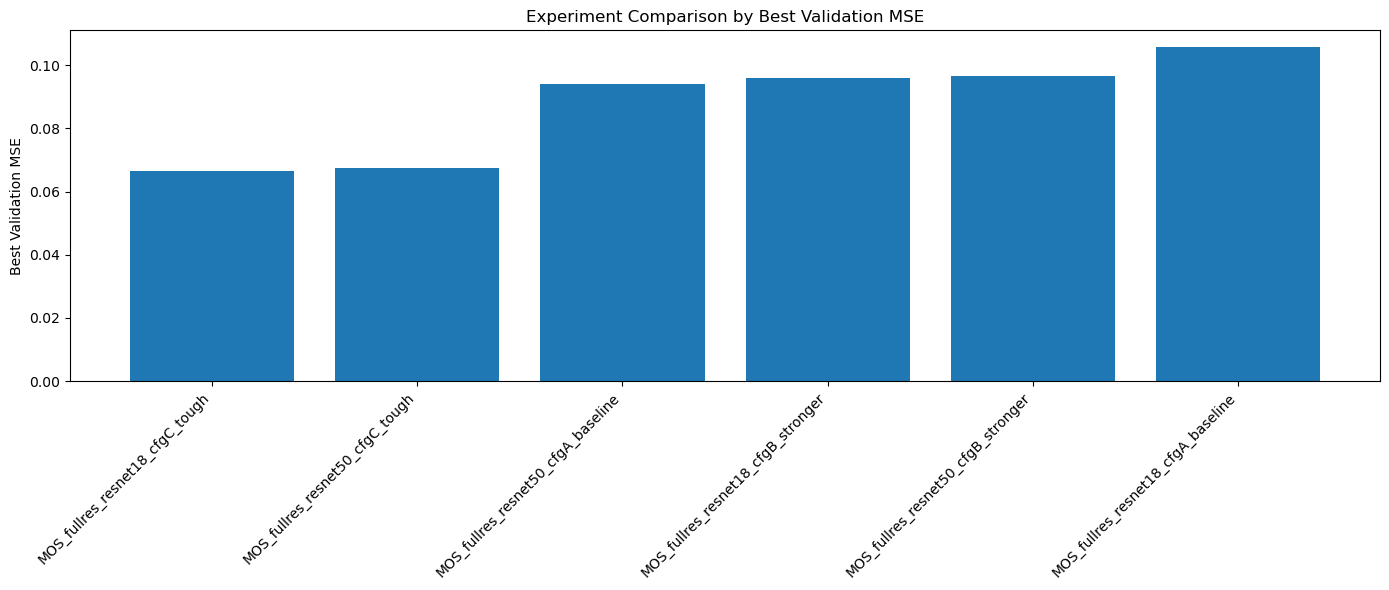


Best experiment:
task_name                               MOS_fullres_resnet18_cfgC_tough
model_name                                                     resnet18
config_name                                                  cfgC_tough
input_size                                                          384
batch_size                                                            6
best_epoch                                                           18
best_val_mse                                                   0.066487
test_mse                                                       0.061968
test_mae                                                       0.190103
test_rmse                                                      0.248935
model_path      outputs/models/MOS_fullres_resnet18_cfgC_tough_best.pth
Name: 0, dtype: object


In [18]:
# ============================================================
# 6.0 Comparison evaluation
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="best_val_mse", ascending=True).reset_index(drop=True)

display(results_df)

results_csv = RESULTS_DIR / "experiment_comparison.csv"
results_df.to_csv(results_csv, index=False)
print(f"Saved comparison table to: {results_csv}")

# simple comparison chart
plt.figure(figsize=(14, 6))
plt.bar(results_df["task_name"], results_df["best_val_mse"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Best Validation MSE")
plt.title("Experiment Comparison by Best Validation MSE")
plt.tight_layout()
plt.show()

best_row = results_df.iloc[0]
print("\nBest experiment:")
print(best_row)

## 4. Advanced Experiment

In [17]:
# ============================================================
# 7.0 Patch dataset and dataloader for aspect-ratio-preserving input
# ============================================================

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class KoniqDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, target_col: str, input_size=None, is_train: bool=False,
                 input_height=None, input_width=None):
        self.frame = frame.reset_index(drop=True).copy()
        self.target_col = target_col
        self.is_train = is_train

        # backward-compatible:
        # if input_height/input_width are not given, use square input_size
        if input_height is None or input_width is None:
            if input_size is None:
                raise ValueError("Either input_size or both input_height/input_width must be provided.")
            input_height = input_size
            input_width = input_size

        self.input_height = int(input_height)
        self.input_width = int(input_width)

        self.transform = self._build_transform()

    def _build_transform(self):
        if self.is_train:
            return transforms.Compose([
                transforms.Resize((self.input_height, self.input_width)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                ),
            ])
        else:
            return transforms.Compose([
                transforms.Resize((self.input_height, self.input_width)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]
                ),
            ])

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row["img_path"]).convert("RGB")
        y = torch.tensor(float(row[self.target_col]), dtype=torch.float32)
        return self.transform(img), y


def create_dataloaders(split_df: pd.DataFrame, exp_config: dict):
    train_df = split_df[split_df["split"] == "train"].copy()
    val_df = split_df[split_df["split"] == "val"].copy()
    test_df = split_df[split_df["split"] == "test"].copy()

    input_size = exp_config.get("input_size", None)
    input_height = exp_config.get("input_height", None)
    input_width = exp_config.get("input_width", None)

    train_ds = KoniqDataset(
        train_df, TARGET_COL,
        input_size=input_size,
        input_height=input_height,
        input_width=input_width,
        is_train=True
    )
    val_ds = KoniqDataset(
        val_df, TARGET_COL,
        input_size=input_size,
        input_height=input_height,
        input_width=input_width,
        is_train=False
    )
    test_ds = KoniqDataset(
        test_df, TARGET_COL,
        input_size=input_size,
        input_height=input_height,
        input_width=input_width,
        is_train=False
    )

    num_workers = int(exp_config.get("num_workers", 4))
    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_ds,
        batch_size=exp_config["batch_size"],
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=exp_config["batch_size"],
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=exp_config["batch_size"],
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=(num_workers > 0),
    )
    return train_loader, val_loader, test_loader

print("Patched dataset/dataloader to support non-square input.")

Patched dataset/dataloader to support non-square input.


In [18]:
# ============================================================
# 8.0 Define two guess-validation large-input experiments
# Keep cfgC_tough training params, only change input to 384x512
# ============================================================

GUESS_VALIDATION_EXPERIMENTS = [
    {
        "project_name": "Stage2-MOS",
        "task_name": "MOS_guess_validation_resnet18_aspect384x512",
        "model_name": "resnet18",
        "config_name": "guess_validation_biginput",
        "dataset_name": "KonIQ-10k",
        "image_source_resolution": "1024x768_full",
        "task_type": "MOS_regression",
        "target_column": TARGET_COL,
        "seed": SEED,

        # keep tough params
        "input_height": 384,
        "input_width": 512,
        "batch_size": 6,
        "phase1_epochs": 5,
        "phase2_epochs": 20,
        "phase1_lr": 2e-4,
        "phase2_lr": 8e-5,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "num_workers": 4,
    },
    {
        "project_name": "Stage2-MOS",
        "task_name": "MOS_guess_validation_resnet50_aspect384x512",
        "model_name": "resnet50",
        "config_name": "guess_validation_biginput",
        "dataset_name": "KonIQ-10k",
        "image_source_resolution": "1024x768_full",
        "task_type": "MOS_regression",
        "target_column": TARGET_COL,
        "seed": SEED,

        # keep tough params
        "input_height": 384,
        "input_width": 512,
        "batch_size": 6,
        "phase1_epochs": 5,
        "phase2_epochs": 20,
        "phase1_lr": 2e-4,
        "phase2_lr": 8e-5,
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "num_workers": 4,
    },
]

# ============================================================
# Quick patch: add input_size field for aspect-ratio experiments
# ============================================================

for exp in GUESS_VALIDATION_EXPERIMENTS:
    if "input_size" not in exp:
        exp["input_size"] = f'{exp["input_height"]}x{exp["input_width"]}'

for exp in GUESS_VALIDATION_EXPERIMENTS:
    print(exp["task_name"], "->", exp["input_size"])

MOS_guess_validation_resnet18_aspect384x512 -> 384x512
MOS_guess_validation_resnet50_aspect384x512 -> 384x512


In [19]:
# ============================================================
# 9.0 Run the two new guess-validation experiments
# ============================================================

extra_results = []

for exp in GUESS_VALIDATION_EXPERIMENTS:
    print("\n" + "=" * 100)
    print("Starting extra experiment:", exp["task_name"])
    result = run_experiment(exp, split_df)
    extra_results.append(result)

print("\nTwo extra experiments finished.")
display(pd.DataFrame(extra_results))


Starting extra experiment: MOS_guess_validation_resnet18_aspect384x512
Previous ClearML task closed.
ClearML Task: created new task id=ff476b13fb914fa4a4cd0eaf578f023a
ClearML results page: https://app.clear.ml/projects/9744a375a0194450ac234ae680404a18/experiments/ff476b13fb914fa4a4cd0eaf578f023a/output/log

Running experiment: MOS_guess_validation_resnet18_aspect384x512
Starting Phase 1 for MOS_guess_validation_resnet18_aspect384x512


/tmp/ipykernel_31519/751824047.py:159: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

/tmp/ipykernel_31519/751824047.py:159: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



[MOS_guess_validation_resnet18_aspect384x512] Epoch 01 | train_loss=0.3635 | val_mse=0.3561 | val_mae=0.4475
[MOS_guess_validation_resnet18_aspect384x512] Epoch 02 | train_loss=0.2380 | val_mse=0.2803 | val_mae=0.3989
[MOS_guess_validation_resnet18_aspect384x512] Epoch 03 | train_loss=0.2062 | val_mse=0.2563 | val_mae=0.3855
[MOS_guess_validation_resnet18_aspect384x512] Epoch 04 | train_loss=0.2043 | val_mse=0.2515 | val_mae=0.3779
[MOS_guess_validation_resnet18_aspect384x512] Epoch 05 | train_loss=0.1937 | val_mse=0.2640 | val_mae=0.3847
Starting Phase 2 for MOS_guess_validation_resnet18_aspect384x512
[MOS_guess_validation_resnet18_aspect384x512] Epoch 06 | train_loss=0.1692 | val_mse=0.1542 | val_mae=0.2974
[MOS_guess_validation_resnet18_aspect384x512] Epoch 07 | train_loss=0.1111 | val_mse=0.1024 | val_mae=0.2461
[MOS_guess_validation_resnet18_aspect384x512] Epoch 08 | train_loss=0.0932 | val_mse=0.0990 | val_mae=0.2384
[MOS_guess_validation_resnet18_aspect384x512] Epoch 09 | train_

███████████████████████████████ 100% | 42.72/42.72 MB [00:03<00:00, 11.00MB/s]: 



Starting extra experiment: MOS_guess_validation_resnet50_aspect384x512
ClearML Task: created new task id=220e7072220e4c01b8f43ce61cbb5b3a
ClearML results page: https://app.clear.ml/projects/9744a375a0194450ac234ae680404a18/experiments/220e7072220e4c01b8f43ce61cbb5b3a/output/log

Running experiment: MOS_guess_validation_resnet50_aspect384x512
Starting Phase 1 for MOS_guess_validation_resnet50_aspect384x512


/tmp/ipykernel_31519/751824047.py:159: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



[MOS_guess_validation_resnet50_aspect384x512] Epoch 01 | train_loss=0.8916 | val_mse=0.8710 | val_mae=0.7750
[MOS_guess_validation_resnet50_aspect384x512] Epoch 02 | train_loss=0.3680 | val_mse=0.5881 | val_mae=0.6183
[MOS_guess_validation_resnet50_aspect384x512] Epoch 03 | train_loss=0.2950 | val_mse=0.4691 | val_mae=0.5446
[MOS_guess_validation_resnet50_aspect384x512] Epoch 04 | train_loss=0.2633 | val_mse=0.4852 | val_mae=0.5576
[MOS_guess_validation_resnet50_aspect384x512] Epoch 05 | train_loss=0.2467 | val_mse=0.4362 | val_mae=0.5243
Starting Phase 2 for MOS_guess_validation_resnet50_aspect384x512
[MOS_guess_validation_resnet50_aspect384x512] Epoch 06 | train_loss=0.1388 | val_mse=0.1279 | val_mae=0.2755
[MOS_guess_validation_resnet50_aspect384x512] Epoch 07 | train_loss=0.0801 | val_mse=0.1256 | val_mae=0.2701
[MOS_guess_validation_resnet50_aspect384x512] Epoch 08 | train_loss=0.0615 | val_mse=0.0975 | val_mae=0.2396
[MOS_guess_validation_resnet50_aspect384x512] Epoch 09 | train_

████████████████████████████████ 100% | 90.00/90.0 MB [00:07<00:00, 11.55MB/s]: 



Two extra experiments finished.


,task_name,model_name,config_name,input_size,batch_size,best_epoch,best_val_mse,test_mse,test_mae,test_rmse,model_path
0,MOS_guess_validation_resnet18_aspect384x512,resnet18,guess_validation_biginput,384x512,6,23,0.065666,0.058742,0.187145,0.242368,outputs/models/MOS_guess_validation_resnet18_aspect384x512_best.pth
1,MOS_guess_validation_resnet50_aspect384x512,resnet50,guess_validation_biginput,384x512,6,24,0.065448,0.062016,0.192162,0.249030,outputs/models/MOS_guess_validation_resnet50_aspect384x512_best.pth


,task_name,model_name,config_name,input_size,batch_size,best_epoch,best_val_mse,test_mse,test_mae,test_rmse,model_path
0,MOS_guess_validation_resnet50_aspect384x512,resnet50,guess_validation_biginput,384x512,6,24,0.065448,0.062016,0.192162,0.249030,outputs/models/MOS_guess_validation_resnet50_aspect384x512_best.pth
1,MOS_guess_validation_resnet18_aspect384x512,resnet18,guess_validation_biginput,384x512,6,23,0.065666,0.058742,0.187145,0.242368,outputs/models/MOS_guess_validation_resnet18_aspect384x512_best.pth
2,MOS_fullres_resnet18_cfgC_tough,resnet18,cfgC_tough,384,6,18,0.066487,0.061968,0.190103,0.248935,outputs/models/MOS_fullres_resnet18_cfgC_tough_best.pth
3,MOS_fullres_resnet50_cfgC_tough,resnet50,cfgC_tough,384,6,20,0.067588,0.063417,0.193209,0.251827,outputs/models/MOS_fullres_resnet50_cfgC_tough_best.pth
4,MOS_fullres_resnet50_cfgA_baseline,resnet50,cfgA_baseline,224,16,14,0.094028,0.092080,0.230748,0.303446,outputs/models/MOS_fullres_resnet50_cfgA_baseline_best.pth
5,MOS_fullres_resnet18_cfgB_stronger,resnet18,cfgB_stronger,224,16,22,0.096031,0.092881,0.237516,0.304763,outputs/models/MOS_fullres_resnet18_cfgB_stronger_best.pth
6,MOS_fullres_resnet50_cfgB_stronger,resnet50,cfgB_stronger,224,16,18,0.096725,0.086829,0.227225,0.294668,outputs/models/MOS_fullres_resnet50_cfgB_stronger_best.pth
7,MOS_fullres_resnet18_cfgA_baseline,resnet18,cfgA_baseline,224,16,14,0.105775,0.099513,0.245135,0.315458,outputs/models/MOS_fullres_resnet18_cfgA_baseline_best.pth


Saved updated comparison table to: outputs/results/experiment_comparison_with_guess_validation.csv


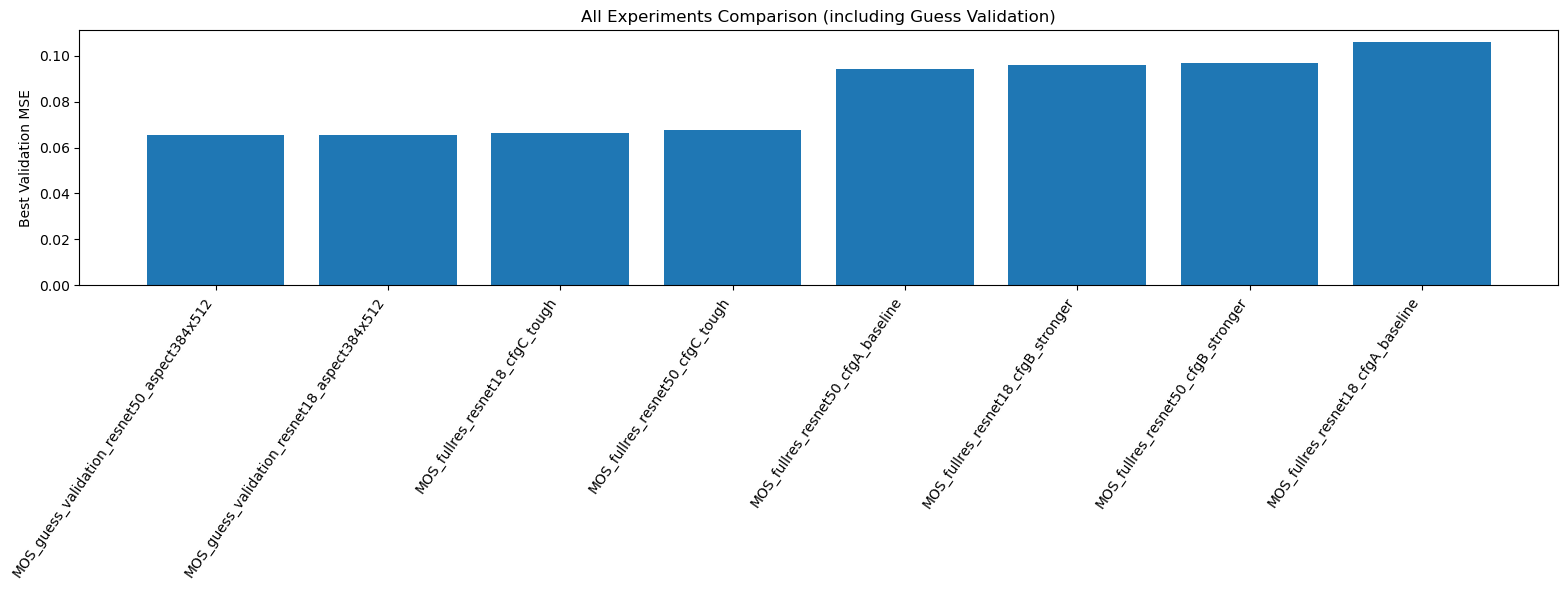


Current best experiment:
task_name                               MOS_guess_validation_resnet50_aspect384x512
model_name                                                                 resnet50
config_name                                               guess_validation_biginput
input_size                                                                  384x512
batch_size                                                                        6
best_epoch                                                                       24
best_val_mse                                                               0.065448
test_mse                                                                   0.062016
test_mae                                                                   0.192162
test_rmse                                                                   0.24903
model_path      outputs/models/MOS_guess_validation_resnet50_aspect384x512_best.pth
Name: 0, dtype: object


In [21]:
# ============================================================
# 10.0 Merge old and new results, then compare again
# ============================================================

extra_results_df = pd.DataFrame(extra_results)

if "results_df" in globals():
    results_df_all = pd.concat([results_df, extra_results_df], axis=0, ignore_index=True)
else:
    # fallback if old results_df is not available in memory
    old_csv = RESULTS_DIR / "experiment_comparison.csv"
    if old_csv.exists():
        old_df = pd.read_csv(old_csv)
        results_df_all = pd.concat([old_df, extra_results_df], axis=0, ignore_index=True)
    else:
        results_df_all = extra_results_df.copy()

results_df_all = results_df_all.sort_values(by="best_val_mse", ascending=True).reset_index(drop=True)

display(results_df_all)

all_csv = RESULTS_DIR / "experiment_comparison_with_guess_validation.csv"
results_df_all.to_csv(all_csv, index=False)
print(f"Saved updated comparison table to: {all_csv}")

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.bar(results_df_all["task_name"], results_df_all["best_val_mse"])
plt.xticks(rotation=55, ha="right")
plt.ylabel("Best Validation MSE")
plt.title("All Experiments Comparison (including Guess Validation)")
plt.tight_layout()
plt.show()

print("\nCurrent best experiment:")
print(results_df_all.iloc[0])